In [2]:
import pandas as pd

   cycle     branch        type                        matchup forecastdate  \
0   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
1   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
2   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
3   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
4   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   

      state   startdate     enddate                  pollster grade  ...  \
0      U.S.  10/25/2016  10/31/2016   Google Consumer Surveys     B  ...   
1      U.S.  10/27/2016  10/30/2016  ABC News/Washington Post    A+  ...   
2  Virginia  10/27/2016  10/30/2016  ABC News/Washington Post    A+  ...   
3   Florida  10/20/2016  10/24/2016                 SurveyUSA     A  ...   
4      U.S.  10/20/2016  10/25/2016       Pew Research Center    B+  ...   

   rawpoll_johnson rawpoll_mcmullin  adjpoll_clinton  adjpoll_trump 

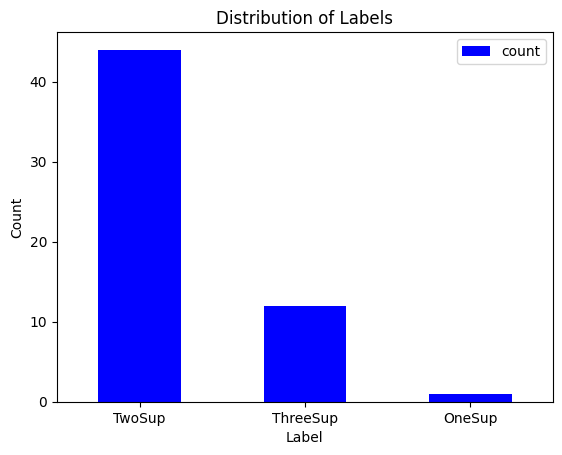

In [4]:
# 读取文件
df = pd.read_csv('23.presidential_polls.csv')
# 查看前5行
print(df.head(5))
# 查看后2行
print(df.tail(2))
# 选择指定列并丢弃缺失值
selected_df = df[['state', 'rawpoll_trump', 'adjpoll_trump']].dropna()
# 导出到文本文件
selected_df.to_csv('presidential_polls_trump.txt', sep=' ', index=False)
# 读取文本文件
text_df = pd.read_csv('presidential_polls_trump.txt', sep=' ')
# 按state分组计算均值
grouped_mean = text_df.groupby('state')[['rawpoll_trump', 'adjpoll_trump']].mean()
# 导出到Excel文件
grouped_mean.to_excel('presidential_polls_trump_state_mean.xlsx')
# 读取Excel文件
excel_df = pd.read_excel('presidential_polls_trump_state_mean.xlsx')
# 进行离散化
category = [0, 25, 50, 75, 100]
labels = ['OneSup', 'TwoSup', 'ThreeSup', 'FourSup']
excel_df['Label'] = pd.cut(excel_df['adjpoll_trump'], bins=category, labels=labels)
# 保存为csv文件
excel_df.to_csv('presidential_polls_trump_state_mean_lable.csv', index=False)
import matplotlib.pyplot as plt
# 重新读取文件
final_df = pd.read_csv('presidential_polls_trump_state_mean_lable.csv')
# 统计个数
counts = final_df['Label'].value_counts()
# 绘制柱状图
counts.plot(kind='bar', color='blue')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.xticks(rotation=0)
plt.legend()
# 保存图片
plt.savefig('presidential_polls_trump_state_support.png', dpi=300)